# GLIMMER on AZT1D and OhioT1DM: findings

*A presentation-style walkthrough of this project's findings. Every chart and table here is built from already-computed results (trained models' saved predictions, the genetic algorithm's saved search results) -- nothing is retrained or re-run to produce this notebook. For the full detailed record, including all code, see notebooks 01-06.*

## Table of contents

1. [The goal](#1-the-goal)
2. [The data](#2-the-data)
3. [What's unusual about this data](#3-whats-unusual-about-this-data)
4. [The models](#4-the-models)
5. [Does this hold up across architectures and datasets](#5-does-this-hold-up-across-architectures-and-datasets)
6. [Bottom line](#6-bottom-line)

## 1. The goal

Predict a person's blood glucose 60 minutes into the future, using their own recent glucose readings, insulin doses, and carbs eaten. The point of the extra warning time is simple: a person (or their pump) can act on a predicted high or low before it actually happens, not just react once it does.

The specific question this project tests: **does it help to train the model to care more about getting dangerous moments right (very high or very low glucose), even at some cost to its accuracy the rest of the time?** That's the core idea of the paper this project replicates ([GLIMMER](https://arxiv.org/abs/2502.14183)).

To make sure any answer to that question is real and not a fluke of one setup, it gets tested three different ways at once:

- **Two model designs** ("architectures"): **CNN-LSTM** and **CNN-Transformer** -- different internal designs, same job, same inputs.
- **Three ways of training each one**, covered in detail in Part 4: an ordinary model, a model told to weight dangerous-zone errors more heavily (using one fixed setting), and a model where that weighting is tuned individually per patient.
- **Two independent, real-world datasets**: AZT1D and OhioT1DM -- different clinics, different patients, different insulin pump hardware.

If an effect only shows up on one architecture, one training approach, or one dataset, it's probably not real. If it shows up consistently across all of them, that's a much stronger result.

## 2. The data

AZT1D is real-world data from 25 people with type 1 diabetes, each using an automated insulin delivery system: a continuous glucose monitor (Dexcom G6 Pro) paired with an insulin pump (Tandem t:slim X2) that automatically adjusts insulin based on glucose trends. Researchers at Mayo Clinic Arizona pulled about a month of data per person straight off each patient's own pump and sensor during routine care, with informed consent and ethics review approval. It's published openly on Mendeley Data by a credentialed academic team. Worth keeping in mind: it's a small, single-clinic sample (25 people) that skews older (ages 27-80, averaging around 60), so results here describe this group, not necessarily everyone with T1D.

**What each 5-minute reading contains:**

- **Glucose (CGM):** measured continuously by a sensor under the skin, in mg/dL. Roughly 70-180 mg/dL is the everyday target range: below 70 is dangerously low (hypoglycemia), above 180 is too high (hyperglycemia).
- **Background ("basal") insulin:** a steady trickle the pump delivers around the clock, in units per hour.
- **Meal-time ("bolus") insulin:** a bigger, one-time dose for a meal or to correct a high, in units.
- **Carbs:** grams of carbohydrate eaten at a logged meal -- what pushes glucose up, and roughly what insulin doses are sized against.

### Who's in the dataset

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>subject_id</th>
      <th>a1c_pct</th>
      <th>sex</th>
      <th>age</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>count</th>
      <td>25.000000</td>
      <td>25.00000</td>
      <td>25</td>
      <td>25.000000</td>
    </tr>
    <tr>
      <th>unique</th>
      <td>NaN</td>
      <td>NaN</td>
      <td>2</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>top</th>
      <td>NaN</td>
      <td>NaN</td>
      <td>Female</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>freq</th>
      <td>NaN</td>
      <td>NaN</td>
      <td>13</td>
      <td>NaN</td>
    </tr>
    <tr>
      <th>mean</th>
      <td>13.000000</td>
      <td>6.63600</td>
      <td>NaN</td>
      <td>59.200000</td>
    </tr>
    <tr>
      <th>std</th>
      <td>7.359801</td>
      <td>0.71232</td>
      <td>NaN</td>
      <td>15.127238</td>
    </tr>
    <tr>
      <th>min</th>
      <td>1.000000</td>
      <td>5.00000</td>
      <td>NaN</td>
      <td>27.000000</td>
    </tr>
    <tr>
      <th>25%</th>
      <td>7.000000</td>
      <td>6.40000</td>
      <td>NaN</td>
      <td>46.000000</td>
    </tr>
    <tr>
      <th>50%</th>
      <td>13.000000</td>
      <td>6.70000</td>
      <td>NaN</td>
      <td>65.000000</td>
    </tr>
    <tr>
      <th>75%</th>
      <td>19.000000</td>
      <td>7.10000</td>
      <td>NaN</td>
      <td>69.000000</td>
    </tr>
    <tr>
      <th>max</th>
      <td>25.000000</td>
      <td>8.20000</td>
      <td>NaN</td>
      <td>80.000000</td>
    </tr>
  </tbody>
</table>
</div>

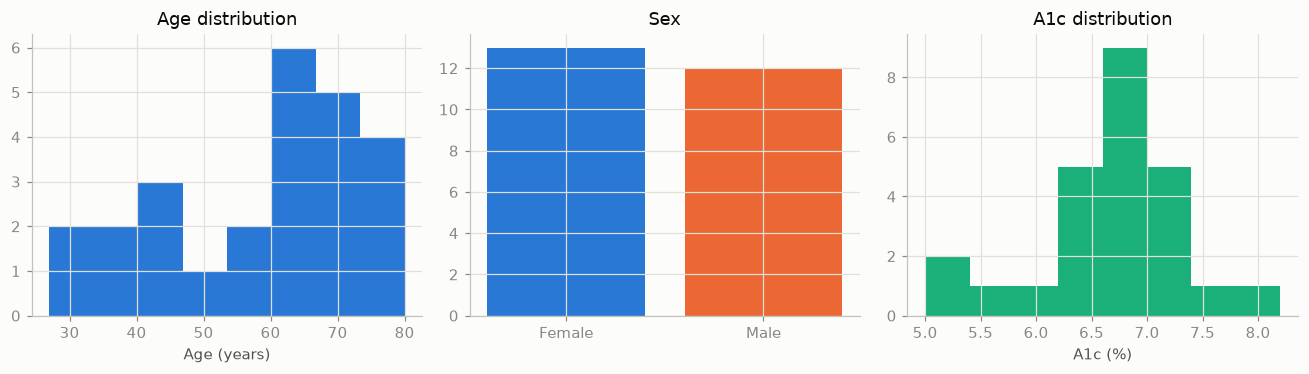

### What one patient's data actually looks like

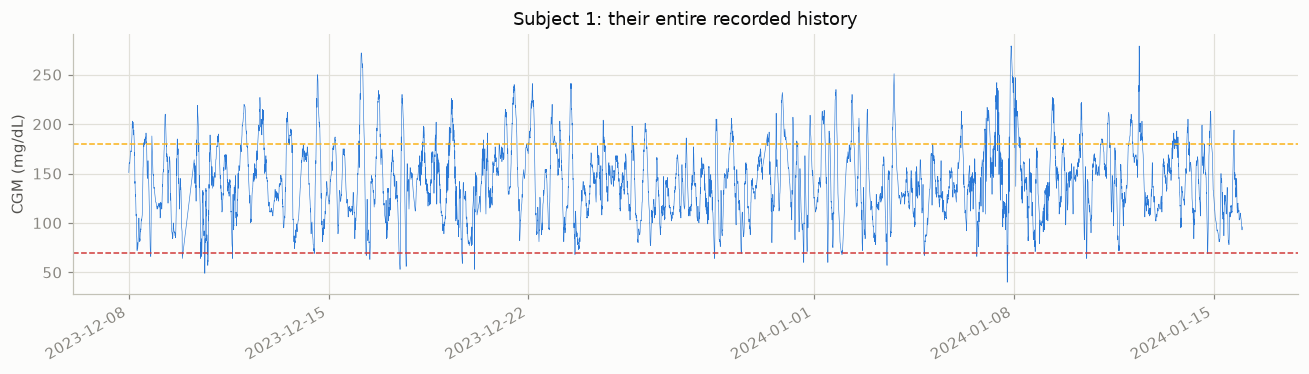

The dashed lines mark the danger thresholds. This one patient spent about 14% of their time above the high line and only about 1% below the low one -- a pattern that holds across the whole group too, covered next.

## 3. What's unusual about this data

A few patterns worth knowing before looking at any model results, since they shape what "doing well" even means here.

### Glucose readings lean high, not low

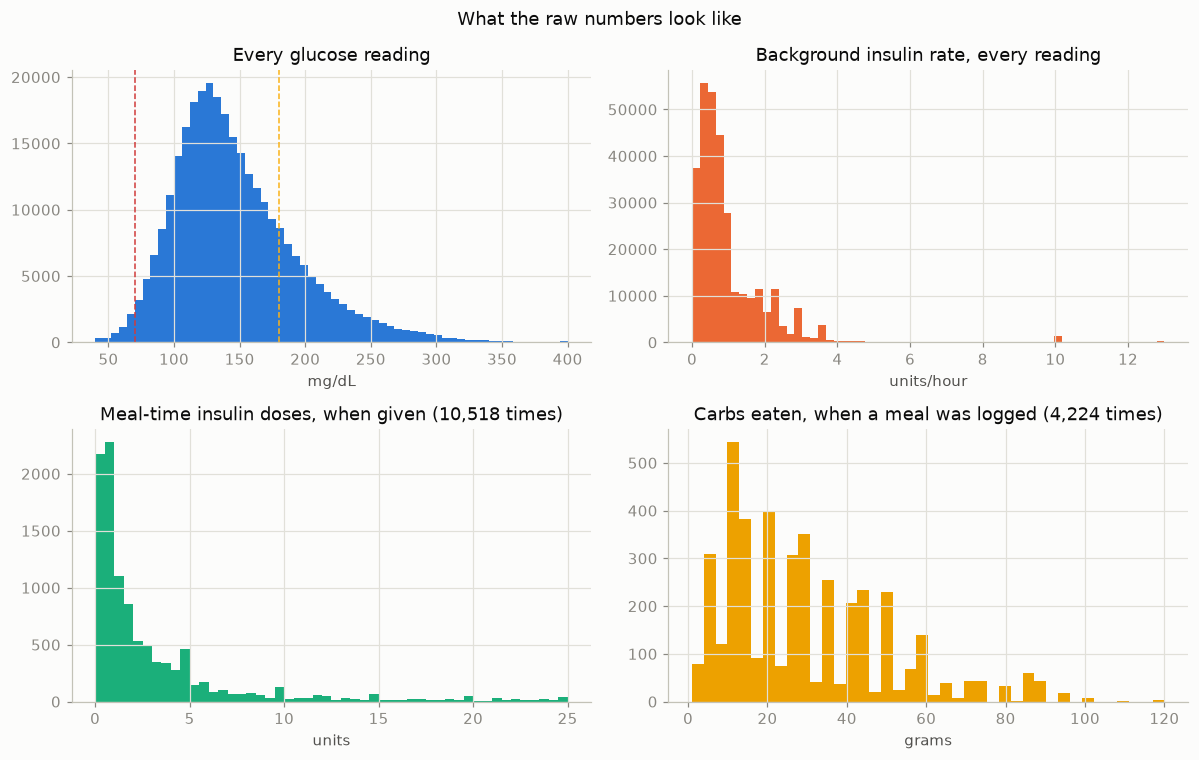

Across the whole group, readings are high (above 180) about 20% of the time but low (below 70) only about 2% of the time. That makes sense two ways: patients and their pumps actively try to avoid going low, since the immediate risk is worse there, and glucose has a hard floor at zero that the high end doesn't have. It also means the hypo cases a model needs to catch are rare to begin with.

### Some patients are much harder to predict for than others

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>CGM</th>
      <th>hypo</th>
      <th>in_range</th>
      <th>hyper</th>
      <th>gmi_pct</th>
      <th>cv_pct</th>
      <th>n_readings</th>
    </tr>
    <tr>
      <th>subject_id</th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>1</th>
      <td>1.0</td>
      <td>84.6</td>
      <td>14.4</td>
      <td>6.7</td>
      <td>25.7</td>
      <td>10881</td>
    </tr>
    <tr>
      <th>2</th>
      <td>0.3</td>
      <td>74.6</td>
      <td>25.1</td>
      <td>7.0</td>
      <td>28.3</td>
      <td>11189</td>
    </tr>
    <tr>
      <th>3</th>
      <td>1.3</td>
      <td>83.4</td>
      <td>15.3</td>
      <td>6.7</td>
      <td>29.2</td>
      <td>10685</td>
    </tr>
    <tr>
      <th>4</th>
      <td>0.1</td>
      <td>63.1</td>
      <td>36.8</td>
      <td>7.4</td>
      <td>31.1</td>
      <td>12750</td>
    </tr>
    <tr>
      <th>5</th>
      <td>4.0</td>
      <td>81.4</td>
      <td>14.6</td>
      <td>6.5</td>
      <td>32.4</td>
      <td>13052</td>
    </tr>
    <tr>
      <th>6</th>
      <td>0.1</td>
      <td>85.2</td>
      <td>14.7</td>
      <td>6.7</td>
      <td>22.8</td>
      <td>12730</td>
    </tr>
    <tr>
      <th>7</th>
      <td>0.9</td>
      <td>85.0</td>
      <td>14.1</td>
      <td>6.7</td>
      <td>25.6</td>
      <td>13385</td>
    </tr>
    <tr>
      <th>8</th>
      <td>0.5</td>
      <td>68.1</td>
      <td>31.3</td>
      <td>7.1</td>
      <td>31.3</td>
      <td>8040</td>
    </tr>
    <tr>
      <th>9</th>
      <td>1.7</td>
      <td>44.8</td>
      <td>53.6</td>
      <td>7.9</td>
      <td>35.3</td>
      <td>10674</td>
    </tr>
    <tr>
      <th>10</th>
      <td>0.9</td>
      <td>70.2</td>
      <td>28.9</td>
      <td>7.0</td>
      <td>33.8</td>
      <td>11881</td>
    </tr>
    <tr>
      <th>11</th>
      <td>0.4</td>
      <td>65.0</td>
      <td>34.6</td>
      <td>7.3</td>
      <td>31.0</td>
      <td>12841</td>
    </tr>
    <tr>
      <th>12</th>
      <td>2.5</td>
      <td>83.5</td>
      <td>14.1</td>
      <td>6.6</td>
      <td>31.3</td>
      <td>12634</td>
    </tr>
    <tr>
      <th>13</th>
      <td>0.4</td>
      <td>92.6</td>
      <td>6.9</td>
      <td>6.5</td>
      <td>21.3</td>
      <td>12801</td>
    </tr>
    <tr>
      <th>14</th>
      <td>6.5</td>
      <td>92.6</td>
      <td>1.0</td>
      <td>5.9</td>
      <td>25.3</td>
      <td>12795</td>
    </tr>
    <tr>
      <th>15</th>
      <td>5.2</td>
      <td>79.2</td>
      <td>15.7</td>
      <td>6.6</td>
      <td>38.8</td>
      <td>13772</td>
    </tr>
    <tr>
      <th>16</th>
      <td>0.6</td>
      <td>76.6</td>
      <td>22.8</td>
      <td>6.9</td>
      <td>31.0</td>
      <td>12248</td>
    </tr>
    <tr>
      <th>17</th>
      <td>1.0</td>
      <td>73.4</td>
      <td>25.6</td>
      <td>7.0</td>
      <td>33.9</td>
      <td>12605</td>
    </tr>
    <tr>
      <th>18</th>
      <td>0.4</td>
      <td>75.1</td>
      <td>24.5</td>
      <td>6.9</td>
      <td>32.3</td>
      <td>10513</td>
    </tr>
    <tr>
      <th>19</th>
      <td>1.3</td>
      <td>89.7</td>
      <td>9.0</td>
      <td>6.5</td>
      <td>26.1</td>
      <td>13092</td>
    </tr>
    <tr>
      <th>20</th>
      <td>1.0</td>
      <td>90.0</td>
      <td>8.9</td>
      <td>6.5</td>
      <td>25.4</td>
      <td>13336</td>
    </tr>
    <tr>
      <th>21</th>
      <td>1.1</td>
      <td>69.5</td>
      <td>29.4</td>
      <td>7.1</td>
      <td>34.9</td>
      <td>13236</td>
    </tr>
    <tr>
      <th>22</th>
      <td>1.3</td>
      <td>82.2</td>
      <td>16.5</td>
      <td>6.7</td>
      <td>28.4</td>
      <td>11350</td>
    </tr>
    <tr>
      <th>23</th>
      <td>1.2</td>
      <td>83.7</td>
      <td>15.2</td>
      <td>6.7</td>
      <td>28.2</td>
      <td>13609</td>
    </tr>
    <tr>
      <th>24</th>
      <td>1.5</td>
      <td>85.0</td>
      <td>13.5</td>
      <td>6.6</td>
      <td>26.4</td>
      <td>10006</td>
    </tr>
    <tr>
      <th>25</th>
      <td>1.1</td>
      <td>67.7</td>
      <td>31.2</td>
      <td>7.2</td>
      <td>33.0</td>
      <td>10818</td>
    </tr>
  </tbody>
</table>
</div>

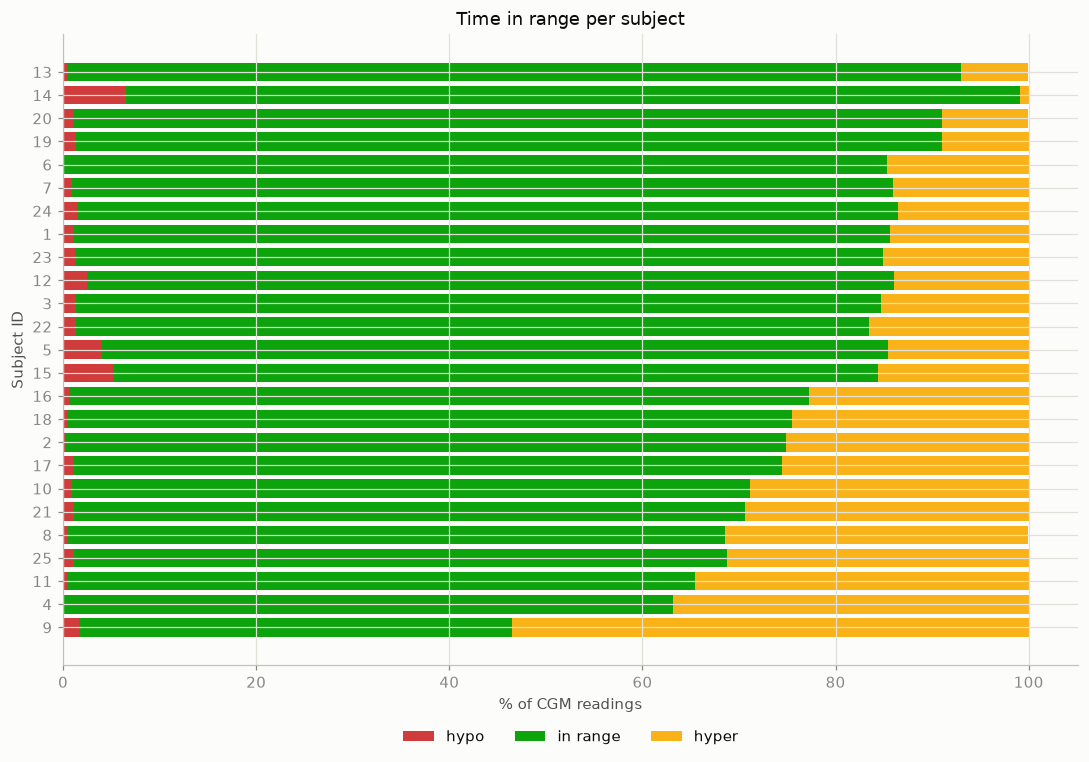

Time spent in the healthy range (70-180 mg/dL) ranges from under 50% for the toughest-controlled patient to over 90% for the best-controlled one. Later on, prediction accuracy tracks this almost exactly -- patients with more erratic glucose are harder to predict for, not because the model is worse at them specifically, but because their own data is intrinsically harder to forecast.

### A few patients are extreme outliers in how much they log

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>total_carbs_g</th>
      <th>total_bolus_u</th>
      <th>total_basal_u</th>
    </tr>
    <tr>
      <th>subject_id</th>
      <th></th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>1</th>
      <td>182.1</td>
      <td>131.0</td>
      <td>49.1</td>
    </tr>
    <tr>
      <th>2</th>
      <td>147.4</td>
      <td>16.1</td>
      <td>7.8</td>
    </tr>
    <tr>
      <th>3</th>
      <td>147.4</td>
      <td>69.4</td>
      <td>53.6</td>
    </tr>
    <tr>
      <th>4</th>
      <td>57.3</td>
      <td>8.8</td>
      <td>20.0</td>
    </tr>
    <tr>
      <th>5</th>
      <td>137.0</td>
      <td>26.2</td>
      <td>9.4</td>
    </tr>
    <tr>
      <th>6</th>
      <td>107.7</td>
      <td>12.4</td>
      <td>11.2</td>
    </tr>
    <tr>
      <th>7</th>
      <td>164.4</td>
      <td>15.1</td>
      <td>11.8</td>
    </tr>
    <tr>
      <th>8</th>
      <td>84.4</td>
      <td>10.3</td>
      <td>10.4</td>
    </tr>
    <tr>
      <th>9</th>
      <td>111.2</td>
      <td>18.7</td>
      <td>27.5</td>
    </tr>
    <tr>
      <th>10</th>
      <td>39.7</td>
      <td>10.2</td>
      <td>48.0</td>
    </tr>
    <tr>
      <th>11</th>
      <td>444.0</td>
      <td>143.4</td>
      <td>34.3</td>
    </tr>
    <tr>
      <th>12</th>
      <td>153.7</td>
      <td>18.4</td>
      <td>14.1</td>
    </tr>
    <tr>
      <th>13</th>
      <td>94.9</td>
      <td>11.0</td>
      <td>6.8</td>
    </tr>
    <tr>
      <th>14</th>
      <td>137.4</td>
      <td>50.7</td>
      <td>13.6</td>
    </tr>
    <tr>
      <th>15</th>
      <td>39.6</td>
      <td>14.2</td>
      <td>15.9</td>
    </tr>
    <tr>
      <th>16</th>
      <td>79.4</td>
      <td>20.2</td>
      <td>44.8</td>
    </tr>
    <tr>
      <th>17</th>
      <td>65.3</td>
      <td>19.9</td>
      <td>22.8</td>
    </tr>
    <tr>
      <th>18</th>
      <td>67.8</td>
      <td>24.5</td>
      <td>48.6</td>
    </tr>
    <tr>
      <th>19</th>
      <td>194.3</td>
      <td>15.6</td>
      <td>6.4</td>
    </tr>
    <tr>
      <th>20</th>
      <td>79.7</td>
      <td>45.4</td>
      <td>50.8</td>
    </tr>
    <tr>
      <th>21</th>
      <td>47.8</td>
      <td>14.6</td>
      <td>24.6</td>
    </tr>
    <tr>
      <th>22</th>
      <td>52.5</td>
      <td>12.5</td>
      <td>10.8</td>
    </tr>
    <tr>
      <th>23</th>
      <td>0.0</td>
      <td>11.6</td>
      <td>7.1</td>
    </tr>
    <tr>
      <th>24</th>
      <td>124.8</td>
      <td>30.0</td>
      <td>12.2</td>
    </tr>
    <tr>
      <th>25</th>
      <td>178.6</td>
      <td>18.3</td>
      <td>17.3</td>
    </tr>
  </tbody>
</table>
</div>

Most patients log a fairly typical amount of carbs and insulin per day, but a couple are far outside that range -- one logs an unusually high amount of carbs daily, another logs almost none. Worth remembering when a specific patient's model results look unusual later: sometimes it's the data, not the model.

### Risk isn't spread evenly across the day

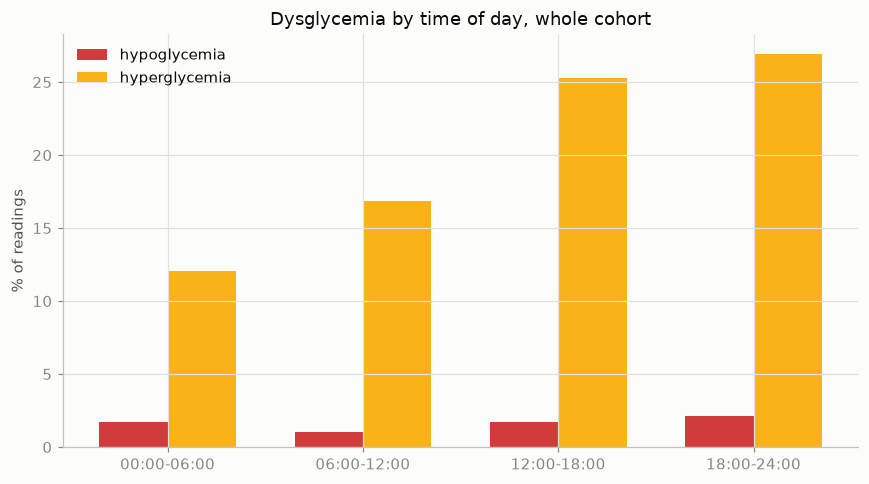

Both highs and lows cluster at certain times of day rather than happening uniformly -- most likely driven by mealtimes and overnight patterns rather than a random spread.

## 4. The models

**How a model is tested:** each patient gets their own personal model (not one model shared across everyone), trained on their own history. It looks at the last 2 hours of glucose/insulin/carb data and predicts glucose 1 hour ahead. The most recent stretch of each patient's data is held back and never shown to the model during training, so every result below is measured on data the model has never seen.

### Approach 1: Standard training

An ordinary model, trained to be right on average, with no special attention to dangerous glucose zones.

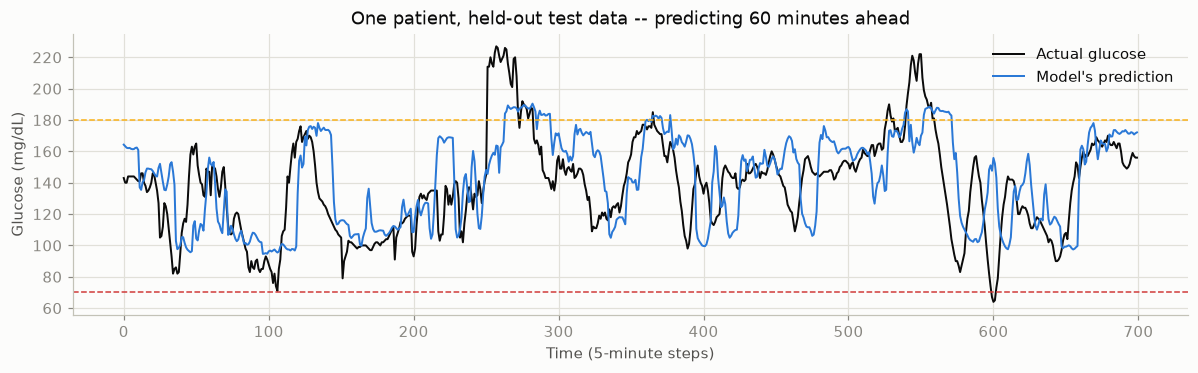

**The problem this motivates:** the prediction tracks the real value well in the middle of the range, but lags and undershoots right at the sharp highs and lows -- exactly the moments that matter most clinically. That gap is what the next two training approaches try to close.

### Approach 2: Fixed danger-weighted training

Same model, same data -- the only change is what it's trained to prioritize. Every prediction error gets sorted into one of three zones based on the true glucose value (hypo, normal, hyper), and errors in the hypo and hyper zones are counted as more costly than errors in the normal zone, using one fixed setting applied to every patient equally.

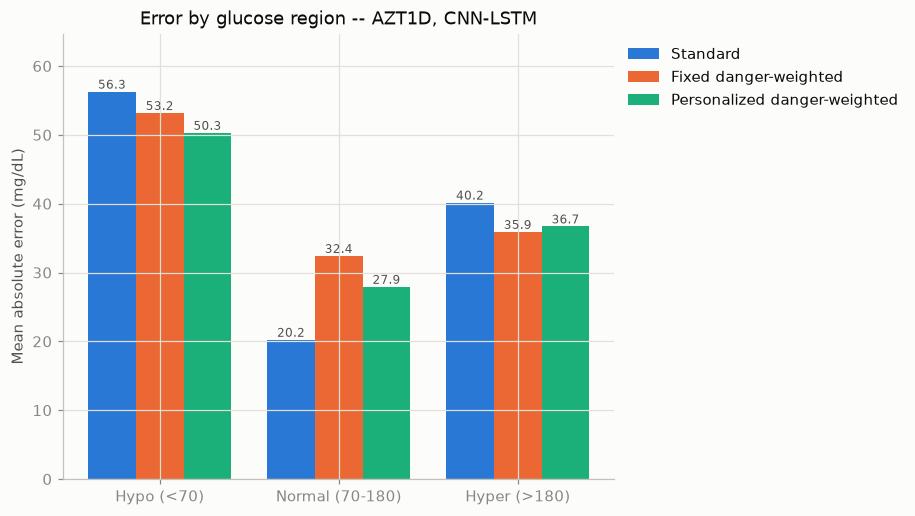

This is the actual mechanism: error in the hypo and hyper zones goes down, exactly as intended, but error in the normal zone goes up enough that the model's overall accuracy (averaged across everything) ends up worse than the standard model's. A real trade-off, not a straightforward win.

**Does that trade-off matter clinically?** Two more direct checks:

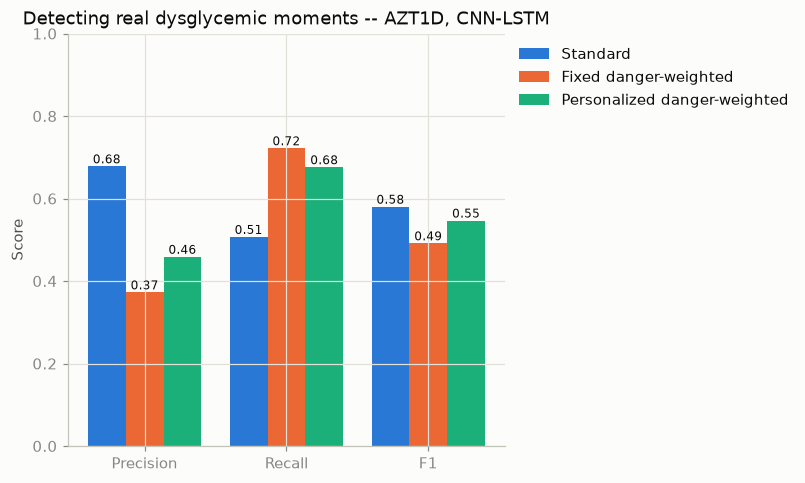

Fixed danger-weighting pushes recall (catching real dangerous moments) up substantially, at the cost of precision (more false alarms). Personalized weighting lands in between the two, closer to standard -- a smaller version of the same trade-off, not a different one.

The Clarke Error Grid is the standard clinical-accuracy tool for glucose predictions, grading every prediction into one of five zones by how much the error would actually matter: **zone A** is clinically accurate, **zone D** means a real dangerous moment got predicted as safe -- the worst kind of miss for a warning system -- and **zone E** is the worst case in the other direction.

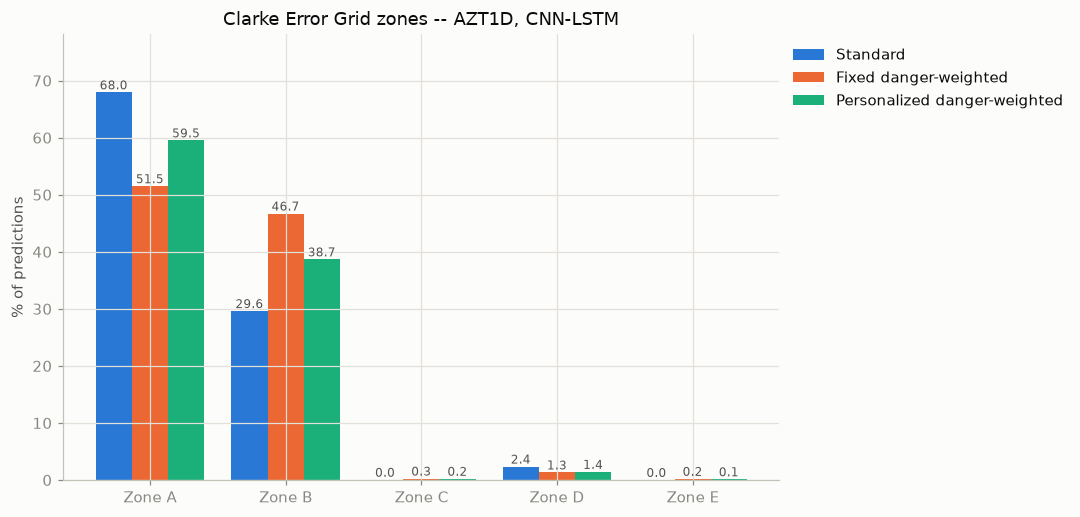

Zone D drops meaningfully with danger-weighted training -- fewer of the misses that would actually matter, even though zone A (plain accuracy) drops too.

### Approach 3: Personalized danger-weighted training

The fixed weighting above applies one setting to every patient. This approach instead searches for each patient's own best weights individually, using a genetic algorithm: many candidate weight settings are tried per patient, the best-performing ones are combined and mutated, and this repeats until it converges on that patient's own best setting.

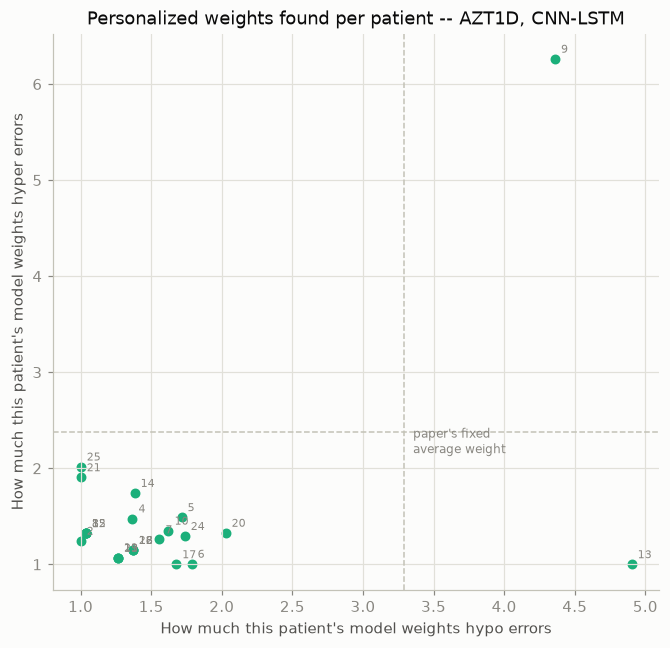

The weights different patients actually need vary a lot -- some barely need any adjustment, a few need a much stronger correction than the fixed setting used above. That spread is the reason to expect personalization to help: one setting for everyone is a compromise, and compromises fit some people better than others.

## 5. Does this hold up across architectures and datasets

Everything above used one architecture (CNN-LSTM) on one dataset (AZT1D), to explain the idea clearly. Here's the same three training approaches, both architectures, both datasets.

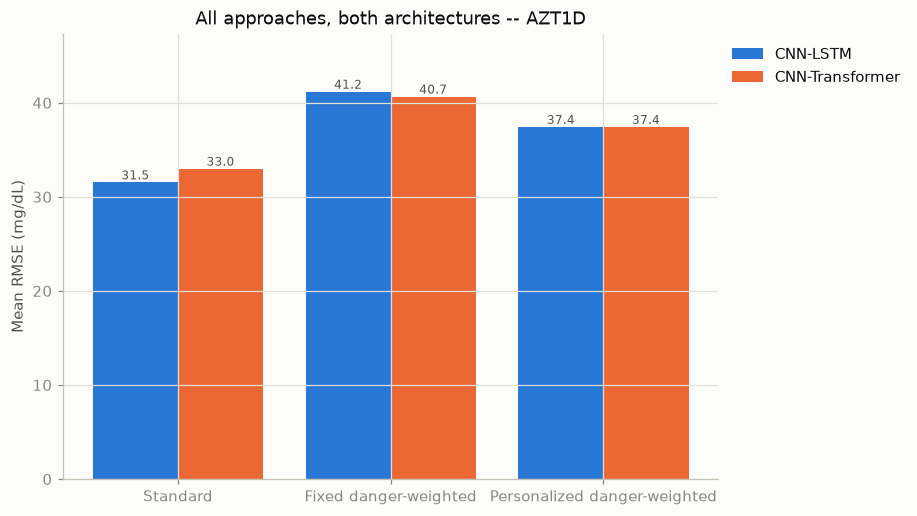

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Standard RMSE</th>
      <th>Fixed danger-weighted RMSE</th>
      <th>Personalized danger-weighted RMSE</th>
    </tr>
    <tr>
      <th>Architecture</th>
      <th></th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>CNN-LSTM</th>
      <td>31.54 +/- 6.10</td>
      <td>41.18 +/- 5.88</td>
      <td>37.44 +/- 6.35</td>
    </tr>
    <tr>
      <th>CNN-Transformer</th>
      <td>32.99 +/- 6.87</td>
      <td>40.66 +/- 4.92</td>
      <td>37.43 +/- 5.49</td>
    </tr>
  </tbody>
</table>

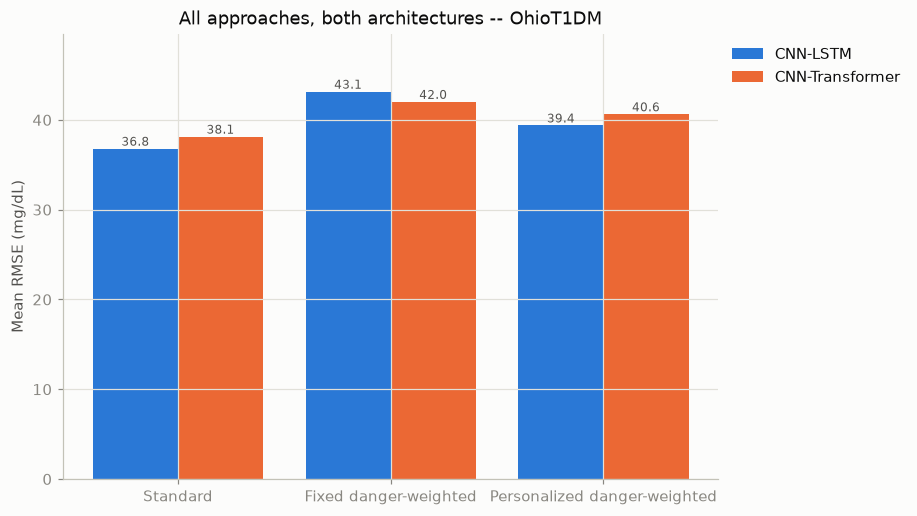

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Standard RMSE</th>
      <th>Fixed danger-weighted RMSE</th>
      <th>Personalized danger-weighted RMSE</th>
    </tr>
    <tr>
      <th>Architecture</th>
      <th></th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>CNN-LSTM</th>
      <td>36.79 +/- 4.37</td>
      <td>43.14 +/- 6.51</td>
      <td>39.38 +/- 6.46</td>
    </tr>
    <tr>
      <th>CNN-Transformer</th>
      <td>38.13 +/- 4.40</td>
      <td>42.01 +/- 6.17</td>
      <td>40.63 +/- 5.36</td>
    </tr>
  </tbody>
</table>

The pattern holds on both architectures and both datasets: standard training is the most accurate on average, fixed danger-weighting is the least accurate, and personalized weighting recovers some but not all of that gap. Four independent tests (2 architectures x 2 datasets) landing on the same pattern is good evidence this is real and not specific to one model or one dataset.

Two things worth flagging: the (3.29, 2.38) fixed weights used above actually came from a genetic algorithm search on OhioT1DM specifically (the paper's own choice, not this project's). Running the same personalized search on OhioT1DM directly -- the most direct check available -- found consistently gentler weights than that reference value, not stronger ones. And on OhioT1DM specifically, the fixed weighting actually beat personalized tuning in the hypo zone, the one place the two datasets disagreed.

## 6. Bottom line

Danger-weighted training is a real trade, not a free win: it makes the model less accurate on average but more likely to catch the moments that actually matter clinically -- more real hypo/hyper events detected, and meaningfully fewer dangerous misses on the Clarke Error Grid. Personalizing those weights per patient, instead of using one fixed setting, recovers some but not all of the accuracy that fixed weighting gives up, consistently across both model designs and both real-world datasets tested.

The gap between this project's numbers and the original paper's reported numbers is most likely the size of the genetic algorithm search used here (deliberately scoped down for compute reasons, see `azt1d/glimmer/ga.py`) -- a larger search budget is the one concrete next step if this needs to go further.